# Reproducing Figures 1-3 from arXiv:0709.2701 with `yellin`

This notebook recreates the first three figures in S. Yellin, *Extending the Optimum Interval Method* ([arXiv:0709.2701](https://arxiv.org/pdf/0709.2701)), using the framework in this repository.

Notes:
- Figure 1 compares $C_{20}(x;50)$ and $C_\infty(y;f)$.
- Figure 2 plots $\bar{C}_{\max}(0.9,f,\mu)$ versus $\mu$ for $f=0,0.02,0.1,0.5$ with $A+B/\sqrt{\mu}$ extrapolation.
- Figure 3 plots $\sigma_{\mathrm{Med}}/\sigma_{\mathrm{True}}$ versus $\mu$ (no background), comparing Poisson and optimum interval.
- Runtime/precision is controlled by constants below.


In [1]:
import sys
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2


def find_repo_root(start: Path) -> Path:
    """Find project root robustly even when notebook runs from notebooks/."""
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src" / "yellin").exists():
            return p
    raise FileNotFoundError("Could not locate repo root containing pyproject.toml and src/yellin")


ROOT = find_repo_root(Path.cwd().resolve())
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from yellin.c_infinity import c_infinity
from yellin.intervals import compute_CMax
from yellin.upper_limit import upper_limit
from yellin.spectrum import SpectrumCDF, uniform_spectrum

DATA_DIR = ROOT / "src" / "yellin" / "data"
print(f"Using repo root: {ROOT}")


Using repo root: /Users/lanqingyuan/Documents/GitHub/yellin


In [9]:
# Tunable runtime / precision settings.
C_LEVEL = 0.9

FIG1_TRIALS = 100_000
FIG3_TRIALS_OI = 200          # optimum-interval MC per mu point (slower)
FIG3_TRIALS_POISSON = 30_000  # Poisson MC per mu point (fast)

# Figure 2 settings.
FIG2_FMIN_VALUES = [0.0, 0.02, 0.1, 0.5]

# Match paper-like x locations for plotted points.
FIG2_MU_DATA = np.geomspace(55.0, 15310.0, 31)
FIG2_MU_CURVE = np.geomspace(55.0, 15310.0, 900)

# Build/fit calibration from tractable MC mu range, then extrapolate with A + B/sqrt(mu).
FIG2_CALIB_MU_VALUES = np.geomspace(55.0, 2000.0, 25)
FIG2_CALIB_TRIALS = 250
FIG2_CALIB_SEED = 12345
FIG2_FIT_MU_MIN = 500.0

FIG2_USE_DENSE_MC = True
FIG2_FORCE_RECOMPUTE = False
FIG2_ENFORCE_MONOTONIC_MU = True
FIG2_ENFORCE_NON_CROSSING = True
FIG2_NON_CROSSING_EPS = 2e-4
FIG2_DENSE_CACHE = ROOT / "notebooks" / "cache" / "fig2_cbar_dense.pkl"

# Paper's high-statistics method is for mu > 54.5.
FIG3_MU_VALUES = np.array([20, 55, 80, 120, 200, 350, 500, 800, 1200, 2000, 5000, 10000], dtype=float)


In [3]:
def largest_x_with_exact_n(F_sorted: np.ndarray, n: int, mu: float) -> float:
    """Largest interval size x=mu*f that contains exactly n events."""
    N = F_sorted.size
    if N < n:
        return mu
    edges = np.concatenate(([0.0], F_sorted, [1.0]))
    f_max = np.max(edges[n + 1 :] - edges[: N - n + 1])
    return float(mu * f_max)


def simulate_cn_curve(
    n: int,
    mu: float,
    x_grid: np.ndarray,
    n_trials: int,
    seed: int = 42,
) -> np.ndarray:
    """Empirical C_n(x; mu) = P(X_n < x), where X_n is max x with n events."""
    rng = np.random.default_rng(seed)
    x_max = np.empty(n_trials, dtype=float)
    for i in range(n_trials):
        N = rng.poisson(mu)
        F = np.sort(rng.random(N)) if N > 0 else np.empty(0, dtype=float)
        x_max[i] = largest_x_with_exact_n(F, n, mu)
    x_max.sort()
    return np.searchsorted(x_max, x_grid, side="left") / n_trials


def c_infinity_from_x(n: int, mu: float, x_grid: np.ndarray) -> np.ndarray:
    """Map x -> (y, f) and evaluate C_infinity(y; f)."""
    f = np.clip(x_grid / mu, 1e-6, 0.999)
    y = (n - x_grid) / np.sqrt(x_grid)
    return np.array([c_infinity(float(yy), float(ff)) for yy, ff in zip(y, f)])


def fit_A_plus_B_over_sqrt(z: np.ndarray, values: np.ndarray) -> tuple[float, float]:
    """Fit values(z) = A + B/sqrt(z)."""
    x = 1.0 / np.sqrt(np.asarray(z, dtype=float))
    slope, intercept = np.polyfit(x, np.asarray(values, dtype=float), 1)
    return float(intercept), float(slope)


def load_cbar_tables(data_dir: Path = DATA_DIR):
    """Load c_bar_max lookup payload from src/yellin/data."""
    table_path = data_dir / "c_bar_max_table.pkl"
    if not table_path.exists():
        raise FileNotFoundError(
            f"Missing {table_path}. Run scripts/generate_c_bar_max_table.py first."
        )
    with open(table_path, "rb") as f:
        payload = pickle.load(f)
    return payload["tables"], payload.get("fits", {})


def simulate_cbar_point(
    mu: float,
    fmin: float,
    C: float,
    n_trials: int,
    rng: np.random.Generator,
) -> float:
    """Monte Carlo estimate of barC_max(C, fmin, mu)."""
    cmax_vals = np.empty(n_trials, dtype=float)
    for i in range(n_trials):
        n_evt = rng.poisson(mu)
        F = np.sort(rng.random(n_evt)) if n_evt > 0 else np.empty(0, dtype=float)
        cmax_vals[i] = compute_CMax(F, mu, fmin)
    return float(np.quantile(cmax_vals, C))


def build_dense_cbar_tables(
    C: float,
    fmin_values: list[float],
    mu_values: np.ndarray,
    n_trials: int,
    seed: int = 12345,
) -> dict:
    """Build dense c_bar_max tables with many mu points for Figure 2."""
    rng = np.random.default_rng(seed)
    mu_values = np.asarray(mu_values, dtype=float)
    tables: dict[tuple[float, float], tuple[np.ndarray, np.ndarray]] = {}

    for fmin in fmin_values:
        out = np.empty(mu_values.size, dtype=float)
        print(f"Building dense table for f={fmin:g} with {mu_values.size} mu points...")
        for j, mu in enumerate(mu_values):
            out[j] = simulate_cbar_point(mu, fmin, C=C, n_trials=n_trials, rng=rng)
            if (j + 1) % max(1, mu_values.size // 8) == 0 or (j + 1) == mu_values.size:
                print(f"  f={fmin:g}: {j+1}/{mu_values.size} points")
        tables[(round(C, 4), round(fmin, 4))] = (mu_values.copy(), out)

    return tables


def load_or_build_fig2_dense_tables(
    cache_path: Path,
    C: float,
    fmin_values: list[float],
    mu_values: np.ndarray,
    n_trials: int,
    seed: int,
    force_recompute: bool = False,
) -> dict:
    """Load dense Figure-2 calibration from cache or build it."""
    cache_path = Path(cache_path)
    mu_values = np.asarray(mu_values, dtype=float)
    fmin_rounded = [round(x, 4) for x in fmin_values]

    if cache_path.exists() and not force_recompute:
        with open(cache_path, "rb") as f:
            payload = pickle.load(f)
        meta = payload.get("meta", {})
        same = (
            meta.get("C") == round(C, 4)
            and meta.get("fmin_values") == fmin_rounded
            and meta.get("n_trials") == int(n_trials)
            and meta.get("seed") == int(seed)
            and np.allclose(np.asarray(meta.get("mu_values", []), dtype=float), mu_values)
        )
        if same:
            print(f"Loaded dense Figure-2 table from {cache_path}")
            return payload["tables"]
        print("Dense cache exists but settings changed; rebuilding.")

    tables = build_dense_cbar_tables(
        C=C,
        fmin_values=fmin_values,
        mu_values=mu_values,
        n_trials=n_trials,
        seed=seed,
    )

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "meta": {
            "C": round(C, 4),
            "fmin_values": fmin_rounded,
            "mu_values": mu_values.tolist(),
            "n_trials": int(n_trials),
            "seed": int(seed),
        },
        "tables": tables,
    }
    with open(cache_path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved dense Figure-2 table to {cache_path}")
    return tables


def build_parametric_cbar_model(
    C: float,
    fmin: float,
    tables: dict,
    mu_fit_min: float = 500.0,
    enforce_monotonic_mu: bool = True,
) -> dict:
    """Build per-f model with fitted A + B/sqrt(mu)."""
    key = (round(C, 4), round(fmin, 4))
    if key not in tables:
        raise ValueError(f"No table entry for C={C}, fmin={fmin}")

    mu_tab, cbar_tab = tables[key]
    mu_tab = np.asarray(mu_tab, dtype=float)
    cbar_tab = np.asarray(cbar_tab, dtype=float)

    order = np.argsort(mu_tab)
    mu_tab = mu_tab[order]
    cbar_tab = cbar_tab[order]

    if enforce_monotonic_mu:
        cbar_tab = np.maximum.accumulate(cbar_tab)

    fit_mask = mu_tab >= mu_fit_min
    if fit_mask.sum() < 2:
        fit_mask = np.ones_like(mu_tab, dtype=bool)

    A, B = fit_A_plus_B_over_sqrt(mu_tab[fit_mask], cbar_tab[fit_mask])
    return {
        "mu_tab": mu_tab,
        "cbar_tab": cbar_tab,
        "A": A,
        "B": B,
    }


def evaluate_parametric_model(model: dict, mu: np.ndarray) -> np.ndarray:
    """Evaluate A + B/sqrt(mu)."""
    mu = np.asarray(mu, dtype=float)
    return model["A"] + model["B"] / np.sqrt(mu)


def build_fig2_points(
    model: dict,
    mu_points: np.ndarray,
    use_interp_below_calib_max: bool = True,
) -> np.ndarray:
    """Paper-like circles: use MC/interp in calibrated range, parametric beyond."""
    mu_points = np.asarray(mu_points, dtype=float)
    y = evaluate_parametric_model(model, mu_points)

    if use_interp_below_calib_max:
        mu_tab = model["mu_tab"]
        cbar_tab = model["cbar_tab"]
        low = mu_points <= mu_tab[-1]
        if np.any(low):
            y[low] = np.interp(mu_points[low], mu_tab, cbar_tab)
    return y


def enforce_non_crossing(curves: np.ndarray, eps: float = 0.0) -> np.ndarray:
    """Ensure f=0 >= f=0.02 >= f=0.1 >= f=0.5 at every mu."""
    out = np.asarray(curves, dtype=float).copy()
    for i in range(1, out.shape[0]):
        out[i] = np.minimum(out[i], out[i - 1] - eps)
    return out


def poisson_upper_limit_from_n(n_obs: np.ndarray, C: float = 0.9) -> np.ndarray:
    """Exact one-sided Poisson upper limit for signal mean with known b=0."""
    n_obs = np.asarray(n_obs, dtype=int)
    alpha = 1.0 - C
    return 0.5 * chi2.ppf(1.0 - alpha, 2.0 * (n_obs + 1.0))


def median_ratio_poisson(mu_true: float, C: float = 0.9, n_trials: int = 30_000, seed: int = 0) -> float:
    """Median(sigma_UL / sigma_true) for simple Poisson counting."""
    rng = np.random.default_rng(seed)
    n_obs = rng.poisson(mu_true, size=n_trials)
    ul = poisson_upper_limit_from_n(n_obs, C=C)
    return float(np.median(ul) / mu_true)


def median_ratio_optimum_interval(
    mu_true: float,
    fmin: float,
    C: float = 0.9,
    n_trials: int = 200,
    seed: int = 0,
) -> float:
    """Median(sigma_UL / sigma_true) for Yellin optimum interval with no background."""
    rng = np.random.default_rng(seed)
    spec = SpectrumCDF(uniform_spectrum(0.0, 1.0))
    ul = np.empty(n_trials, dtype=float)
    for i in range(n_trials):
        n_evt = rng.poisson(mu_true)
        events = np.sort(rng.random(n_evt)) if n_evt > 0 else np.empty(0, dtype=float)
        ul[i] = upper_limit(events, spec, C=C, fmin=fmin)
    return float(np.median(ul) / mu_true)


## Figure 1

Paper caption summary: compare $C_{20}(x;50)$ (solid) to $C_\infty(y;f)$ (dashed) with
$$y = \frac{n-x}{\sqrt{x}}, \quad f=\frac{x}{\mu}, \quad n=20, \mu=50.$$

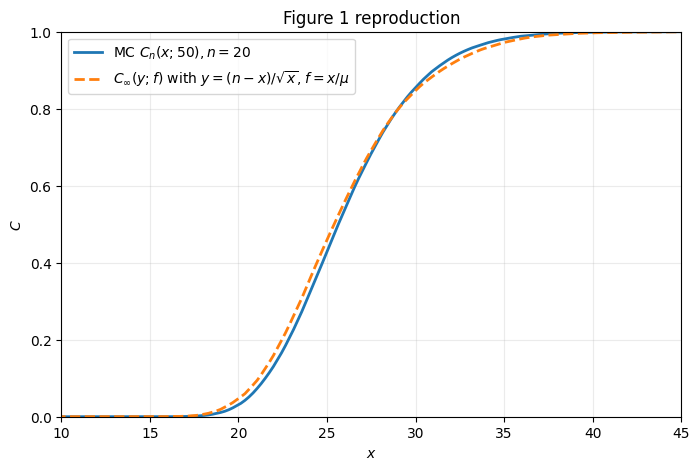

In [8]:
n = 20
mu = 50.0
x_grid = np.linspace(8.0, 49.0, 180)

Cn = simulate_cn_curve(n=n, mu=mu, x_grid=x_grid, n_trials=FIG1_TRIALS, seed=1)
Cinf = c_infinity_from_x(n=n, mu=mu, x_grid=x_grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_grid, Cn, lw=2, label=fr"MC $C_{{n}}(x; {mu:.0f}), n={n}$")
ax.plot(
    x_grid,
    Cinf,
    "--",
    lw=2,
    label=r"$C_\infty(y;f)$ with $y=(n-x)/\sqrt{x}$, $f=x/\mu$",
)
ax.set_xlabel("$x$")
ax.set_ylabel("$C$")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Figure 1 reproduction")
ax.grid(alpha=0.25)
ax.set_ylim(0.0, 1.0)
ax.set_xlim(10.0, 45.0)
ax.legend()
plt.show()


## Figure 2

Paper quantity: $\bar{C}_{\max}(0.9, f, \mu)$ versus $\mu$ for $f=0,0.02,0.1,0.5$.

Loaded dense Figure-2 table from /Users/lanqingyuan/Documents/GitHub/yellin/notebooks/cache/fig2_cbar_dense.pkl
f=0: A=0.987268, B=-0.088980
f=0.02: A=0.984228, B=-0.000000
f=0.1: A=0.990995, B=-0.272272
f=0.5: A=0.987418, B=-0.503229


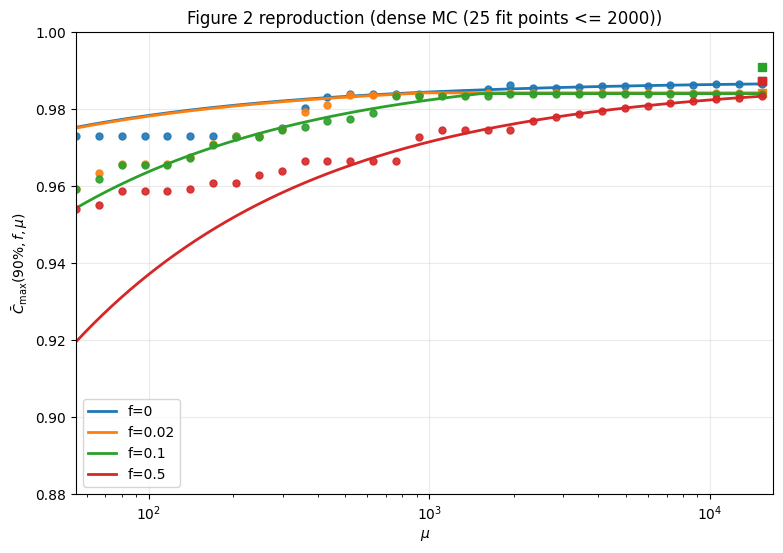

In [5]:
repo_tables, _fits = load_cbar_tables()

if FIG2_USE_DENSE_MC:
    tables = load_or_build_fig2_dense_tables(
        cache_path=FIG2_DENSE_CACHE,
        C=C_LEVEL,
        fmin_values=FIG2_FMIN_VALUES,
        mu_values=FIG2_CALIB_MU_VALUES,
        n_trials=FIG2_CALIB_TRIALS,
        seed=FIG2_CALIB_SEED,
        force_recompute=FIG2_FORCE_RECOMPUTE,
    )
    source_label = f"dense MC ({len(FIG2_CALIB_MU_VALUES)} fit points <= {FIG2_CALIB_MU_VALUES.max():.0f})"
else:
    tables = repo_tables
    source_label = "repo lookup table"

models = {}
for fmin in FIG2_FMIN_VALUES:
    model = build_parametric_cbar_model(
        C=C_LEVEL,
        fmin=fmin,
        tables=tables,
        mu_fit_min=FIG2_FIT_MU_MIN,
        enforce_monotonic_mu=FIG2_ENFORCE_MONOTONIC_MU,
    )
    models[fmin] = model
    print(f"f={fmin:g}: A={model['A']:.6f}, B={model['B']:.6f}")

mu_points = FIG2_MU_DATA
mu_curve = FIG2_MU_CURVE

points_all = []
curves_all = []
for fmin in FIG2_FMIN_VALUES:
    model = models[fmin]
    points_all.append(build_fig2_points(model, mu_points, use_interp_below_calib_max=True))
    curves_all.append(evaluate_parametric_model(model, mu_curve))

points_all = np.array(points_all)
curves_all = np.array(curves_all)

if FIG2_ENFORCE_NON_CROSSING:
    points_all = enforce_non_crossing(points_all, eps=FIG2_NON_CROSSING_EPS)
    curves_all = enforce_non_crossing(curves_all, eps=FIG2_NON_CROSSING_EPS)

fig, ax = plt.subplots(figsize=(9, 6))

for i, fmin in enumerate(FIG2_FMIN_VALUES):
    line = ax.plot(mu_curve, curves_all[i], lw=2, label=f"f={fmin:g}")[0]
    color = line.get_color()
    ax.plot(mu_points, points_all[i], "o", color=color, ms=5, alpha=0.9)
    ax.plot([15310], [models[fmin]["A"]], "s", color=color, ms=6)

ax.set_xscale("log")
ax.set_xlim(55, 15310 * 1.1)
ax.set_ylim(0.88, 1.00)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\bar{C}_{\max}(90\%, f, \mu)$")
ax.set_title(f"Figure 2 reproduction ({source_label})")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.show()


## Figure 3

Paper quantity: $\sigma_{\mathrm{Med}}/\sigma_{\mathrm{True}}$ versus $\mu$ (no background),
comparing simple Poisson upper limits and the optimum interval method.

Here we show:
- Poisson (counting-only),
- Optimum interval with $f=0$,
- Optimum interval with $f=0.2$ (close to the $f=0$ curve, as noted in the paper).


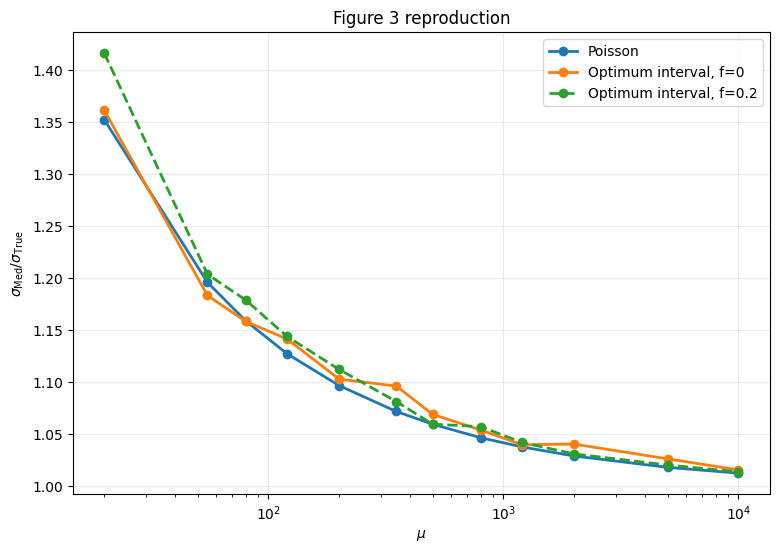

In [10]:
mu_vals = FIG3_MU_VALUES

ratio_poisson = np.array(
    [
        median_ratio_poisson(mu, C=C_LEVEL, n_trials=FIG3_TRIALS_POISSON, seed=1000 + i)
        for i, mu in enumerate(mu_vals)
    ],
    dtype=float,
)

ratio_oi_f0 = np.array(
    [
        median_ratio_optimum_interval(mu, fmin=0.0, C=C_LEVEL, n_trials=FIG3_TRIALS_OI, seed=2000 + i)
        for i, mu in enumerate(mu_vals)
    ],
    dtype=float,
)

ratio_oi_f02 = np.array(
    [
        median_ratio_optimum_interval(mu, fmin=0.2, C=C_LEVEL, n_trials=FIG3_TRIALS_OI, seed=3000 + i)
        for i, mu in enumerate(mu_vals)
    ],
    dtype=float,
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(mu_vals, ratio_poisson, "o-", lw=2, label="Poisson")
ax.plot(mu_vals, ratio_oi_f0, "o-", lw=2, label="Optimum interval, f=0")
ax.plot(mu_vals, ratio_oi_f02, "o--", lw=2, label="Optimum interval, f=0.2")

ax.set_xscale("log")
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma_{\mathrm{Med}}/\sigma_{\mathrm{True}}$")
ax.set_title("Figure 3 reproduction")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.show()
